# Generate caravan Map
In this notebook you will retrieve the geospatial data for the Cravan dataset.The caravan dataset is a collection of streamflow and forcing data. <br>
Caravan was prepared by [Frederik Kratzert](https://doi.org/10.1038/s41597-023-01975-w), the forcing is based on the ERA5-Land model. The streamflow is from the USGS. <br>
To access it easily, it was stored [here](https://doi.org/10.4121/bf0eaf7c-f2fa-46f6-b8cd-77ad939dd350.v4) on the [OPenDAP](https://data.4tu.nl/info/about-your-data/netcdf-and-opendap) server from data.4TU.nl .<br>
This saves you from downloading and reading the whole dataset hosted on [zenodo](https://zenodo.org/records/6578598), instead only the necesarry data is downloaded. 

This notebook will show case how to turn this into an easily accessible map.  

This supplies you with the basin_id.
The shapefiles will be downloaded automatically and the catchment information downloaded from the server


In [1]:
import wget
from zipp import zipfile
from pathlib import Path
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import pandas as pd

import requests
from bs4 import BeautifulSoup
import numpy as np

import folium

Specify url

In [2]:
DCACHE_STORAGE = "/data/shared/climate-data/caravan1_6"

Download the required shapefiles from [data.4TU.nl](https://doi.org/10.4121/bf0eaf7c-f2fa-46f6-b8cd-77ad939dd350.v4)

In [3]:
shape_files =  f"{DCACHE_STORAGE}/shapefiles"

In [4]:
combined_shapefile_path = f"{shape_files}/combined.shp"

Load in the dataset

In [5]:
gdf = gpd.read_file(combined_shapefile_path)

In [6]:
dataset_names = list(set(gdf['gauge_id'].apply(lambda x: x.split('_')[0]).values))
dataset_names

['camels', 'hysets', 'camelsgb', 'camelsbr', 'camelscl', 'camelsaus', 'lamah']

In [7]:
map_path = Path('docs/v1_6')
if not map_path.exists():
    map_path.mkdir()

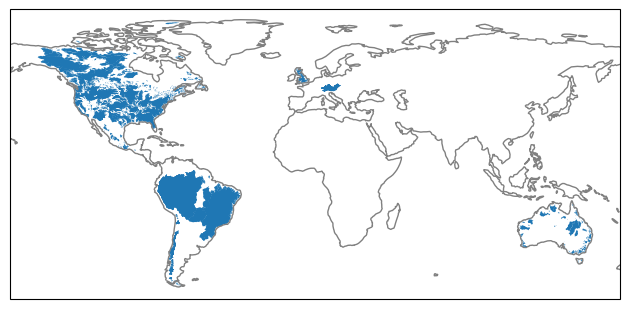

In [8]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, edgecolor='gray')
gdf.plot(ax=ax,zorder=1,color="C0")
plt.tight_layout()
plt.savefig(map_path / 'overview_image_v1_6.png',bbox_inches='tight',dpi=400)

# Load data

In [9]:
import xarray as xr

In [10]:
 def get_camels_ids(dataset: str):
    ds = xr.open_dataset(f"{DCACHE_STORAGE}/{dataset}.nc")
    return np.array([basin for basin in ds['basin_id'].values])

In [11]:
 def get_caravan(dataset: str, basin_id: str):
    ds = xr.open_dataset(f"{DCACHE_STORAGE}/{dataset}.nc")
    return ds.sel(basin_id=basin_id)

In [12]:
def get_dataset(dataset) -> xr.Dataset:
    """Opens specified dataset from data.4tu.nl OPeNDAP server.
    Args:
        dataset (str): name of dataset, choose from:
            'camels',
            'camelsaus',
            'camelsbr',
            'camelscl',
            'camelsgb',
            'hysets',
            'lamah'
    """
    return xr.open_dataset(f"{DCACHE_STORAGE}/{dataset}.nc")


In [13]:
get_camels_ids(dataset_names[-1])[0]

'lamah_10026301'

In [14]:
basin_id= "camels_01022500"
ds = get_caravan("camels", basin_id)

In [15]:
PROPERTY_VARS = [
    "timezone",
    "name",
    "country",
    "lat",
    "lon",
    "area",
    "p_mean",
    "pet_mean_ERA5_LAND",  # was pet_mean, can also do pet_mean_FAO_PM
    "aridity_ERA5_LAND",  # was aridity, can also do aridity_FAO_PM
    "frac_snow",
    "moisture_index_ERA5_LAND",  # was moisture_index, can also do moisture_index_FAO_PM
    "seasonality_ERA5_LAND",  # was seasonality, can also do seasonality_FAO_PM
    "high_prec_freq",
    "high_prec_dur",
    "low_prec_freq",
    "low_prec_dur",
]
RENAME_ERA5 = {
    "total_precipitation_sum": "pr",
    "potential_evaporation_sum": "evspsblpot",
    "temperature_2m_mean": "tas",
    "temperature_2m_min": "tasmin",
    "temperature_2m_max": "tasmax",
    "streamflow": "Q",
}

In [16]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:                                        (time: 26662)
Coordinates:
  * time                                           (time) datetime64[ns] 213kB ...
    basin_id                                       <U15 60B 'camels_01022500'
Data variables: (12/60)
    dewpoint_temperature_2m_max                    (time) float32 107kB ...
    dewpoint_temperature_2m_mean                   (time) float32 107kB ...
    dewpoint_temperature_2m_min                    (time) float32 107kB ...
    potential_evaporation_sum_ERA5_LAND            (time) float32 107kB ...
    potential_evaporation_sum_FAO_PENMAN_MONTEITH  (time) float32 107kB ...
    snow_depth_water_equivalent_max                (time) float32 107kB ...
    ...                                             ...
    moisture_index_FAO_PM                          float64 8B ...
    p_mean                                         float64 8B ...
    pet_mean_ERA5_LAND                             float64 8B ...
    pet_mean_FAO_PM                                float64 8B ...
    seasonality_ERA5_LAND                          float64 8B ...
    seasonality_FAO_PM                             float64 8B ...
Attributes:
    history:  Merged together from separate files; All forcing and state vari...

In [17]:
lst_df_info = []
for dataset_name in dataset_names:
    ds = get_dataset(dataset_name)
    variables = ds.data_vars.keys()
    properties = set(variables).intersection(PROPERTY_VARS)
    non_property_vars = set(variables) - properties
    variable_names = non_property_vars.intersection(
        RENAME_ERA5.keys()
    )  # only take the vars also in Rename dict
    ds = ds.drop_vars(non_property_vars)
    ds = ds.drop_indexes("time")
    ds = ds.drop_vars("time")
    ds['basin_id'] = [val for val in ds['basin_id'].values]
    
    df_info = ds.to_dataframe()
    for val in ['timezone','name', 'country']:
        df_info[val] = df_info[val].apply(
            lambda x: x.decode("ISO-8859-1") if isinstance(x, (bytes, bytearray)) else x
        )
    lst_df_info.append(df_info)

In [18]:
df_combined_info = pd.concat(lst_df_info).sort_index()

In [19]:
df_combined_info['basin_id'] = df_combined_info.index

In [20]:
if 'gauge_id' in gdf.columns:
    gdf = gdf.set_index('gauge_id')

In [21]:
for val in df_combined_info.keys():
    gdf[val] = df_combined_info[val]

In [22]:
# add to gdf

In [23]:
gdf[['timezone','name','country']]

,timezone,name,country
gauge_id,,,
camels_01013500,America/New_York,"Fish River near Fort Kent, Maine",United States of America
camels_01022500,America/New_York,"Narraguagus River at Cherryfield, Maine",United States of America
camels_01030500,America/New_York,"Mattawamkeag River near Mattawamkeag, Maine",United States of America
camels_01031500,America/New_York,"Piscataquis River near Dover-Foxcroft, Maine",United States of America
camels_01047000,America/New_York,"Carrabassett River near North Anson, Maine",United States of America
...,...,...,...
lamah_76184,Europe/Berlin,Schmiech at Ehingen-Berkach,Germany
lamah_76185,Europe/Berlin,Brigach at Villingen,Germany
lamah_76266,Europe/Berlin,Haslach at Rot an der Rot,Germany


Turn it into a Map using folium

In [24]:
# control_bool = True
# caravan_map = folium.Map(
#                     # location        = [NL_outline.iloc[0].geometry.centroid.y, NL_outline.iloc[0].geometry.centroid.x],
#                     # zoom_start      = 8,
#                     # zoom_control    = control_bool,
#                     # scrollWheelZoom = control_bool,
#                     # dragging        = control_bool
#                     )

# catchments = gdf.to_crs(epsg=4326)

# folium.features.GeoJson(catchments,).add_to(caravan_map)

In [25]:
# # icon = folium.features.Icon(color="blue",icon="none")

# gjson = folium.features.GeoJson(
#                                 gdf,
#                                 # marker = folium.features.Marker(icon=icon)
#                                 ).add_to(caravan_map)

# # create
# popup = folium.features.GeoJsonPopup(
#     fields=['name','country','basin_id'],

# ).add_to(gjson)

In [26]:
# caravan_map.save(f"caravan_catchments_map.html")

### Too big, split per country: 

In [27]:
countries = gdf['country'].unique()

In [28]:
import warnings
warnings.simplefilter("ignore") # centroid gives : UserWarning: Geometry is in a geographic CRS

In [29]:
countries

array(['United States of America', 'Australia', 'Brazil', 'Chile',
       'Scotland', 'Great Britain', 'England', 'Wales', 'Canada',
       'Mexico', 'Germany', 'Switzerland', 'Austria', 'Lichtenstein',
       'Czech Republic'], dtype=object)

In [30]:
# fix issue of overlapping polygons
gdf = gdf.sort_values("area",ascending=False)

In [31]:
# This generates html files that are too big for GitHub

for country in countries:
    gdf_country = gdf[gdf['country'] == country]
    country_map = folium.Map(
                        location        = [np.mean(gdf_country.geometry.centroid.y), np.mean(gdf_country.geometry.centroid.x)],
                        zoom_start      = 6,
                        )

    catchments_country = gdf_country.to_crs(epsg=4326)
    
    folium.features.GeoJson(catchments_country,).add_to(country_map)
    gjson = folium.features.GeoJson(
                                gdf_country,
                                # marker = folium.features.Marker(icon=icon)
                                ).add_to(country_map)

    # create
    popup = folium.features.GeoJsonPopup(
        fields=['basin_id','name','country','area',
       'p_mean', 'pet_mean_ERA5_LAND', 'aridity_ERA5_LAND', 'frac_snow', 'moisture_index_ERA5_LAND',
       'seasonality_ERA5_LAND', 'high_prec_freq', 'high_prec_dur', 'low_prec_freq',
       'low_prec_dur'],
    
    ).add_to(gjson)

    country_map.save(map_path / f"caravan_catchments_map_{country.replace(' ','_')}.html")   

In [32]:
popup_fields = ['basin_id', 'name', 'country', 'area',
                'p_mean', 'pet_mean_ERA5_LAND', 'aridity_ERA5_LAND', 'frac_snow',
                'moisture_index_ERA5_LAND', 'seasonality_ERA5_LAND',
                'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur']

for country in countries:
    gdf_country = gdf[gdf['country'] == country].to_crs(epsg=4326).copy()

    # 1. Simplify: tolerance is in metres because we go through EPSG:3857.
    #    Bump 200 up (coarser, smaller) or down (finer, bigger) to taste.
    gdf_country['geometry'] = (
        gdf_country.to_crs(epsg=3857).geometry.simplify(200).to_crs(epsg=4326)
    )

    # 2. Keep only the columns the popup needs — everything else gets
    #    embedded as GeoJSON properties otherwise.
    gdf_country = gdf_country[popup_fields + ['geometry']]

    # 3. Center from the bounding box (avoids the centroid-in-lat/lon warning).
    minx, miny, maxx, maxy = gdf_country.total_bounds
    country_map = folium.Map(location=[(miny + maxy) / 2, (minx + maxx) / 2],
                             zoom_start=6)

    # 4. Add the layer ONCE, with the popup.
    gjson = folium.features.GeoJson(gdf_country).add_to(country_map)
    folium.features.GeoJsonPopup(fields=popup_fields).add_to(gjson)

    country_map.save(map_path / f"caravan_catchments_map_{country.replace(' ', '_')}.html")